In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error, classification_report
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os
import time
from datetime import timedelta
import sys
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [3]:
class CEFRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx]) - 1

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [4]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6
7320,Mapillary использует программное обеспечение д...,6,6


In [5]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Размер обучающей выборки без аугментаций: {len(train_texts)}")
print(f"Размер валидационной выборки без аугментаций: {len(val_texts)}")

Размер обучающей выборки без аугментаций: 5857
Размер валидационной выборки без аугментаций: 1465


In [6]:
def fit(c2):
    model_name = 'sberbank-ai/ruBert-large'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=6,
        id2label={0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'C1', 5: 'C2'},
        label2id={'A1': 0, 'A2': 1, 'B1': 2, 'B2': 3, 'C1': 4, 'C2': 5}
    )
    
    model = model.to(device)
    print(f"Модель инициализирована")

    
    train_labels_aug = train_labels.tolist() + [6]*len(c2)
    train_texts_aug = train_texts.tolist() + c2['augmented-text'].tolist()
    
    train_dataset = CEFRDataset(train_texts_aug, train_labels_aug, tokenizer)
    val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)
    
    print(f"Обучающая выборка с аугментациями: {len(train_texts_aug)}")
    print(f"Валидационная выборка без аугментации: {len(val_texts)}")

    training_args = TrainingArguments(
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        warmup_steps=100,
        weight_decay=0.01,
        logging_steps=100,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,
        learning_rate=2e-5
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )

    train_start_time = time.time()
    trainer.train()
    train_time = time.time() - train_start_time
    print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

    return model, val_dataset, train_time
    

In [7]:
def predict(model, val_dataset, device, train_time):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    accuracy = accuracy_score(true_labels, predictions)
    f1_micro = f1_score(true_labels, predictions, average="micro")
    f1_macro = f1_score(true_labels, predictions, average="macro")
    f1_weighted = f1_score(true_labels, predictions, average="weighted")
    mae = mean_absolute_error(true_labels, predictions)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Micro: {f1_micro:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"MAE: {mae:.4f}")
    print(classification_report(true_labels, predictions))

    print(f"\n\n{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")
    
    return true_labels, predictions

In [8]:
def visualize_cm(true_labels, predictions):
    cm = confusion_matrix(true_labels, predictions)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    
    for i in range(6):
        for j in range(6):
            ax.text(j, i, cm[i, j], ha='center', va='center')
    
    plt.xlabel('Предсказанные')
    plt.ylabel('Истинные')
    plt.title('Матрица ошибок')
    plt.colorbar(im)
    plt.show()
    

# Температура 0.0

In [13]:
c2 = pd.read_csv('c2_augmented_11_temp_0_0.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.044600,0.942778
2,0.554900,1.025291
3,0.149400,1.500596


Обучение завершено за 325.15 секунд (0:05:25)


In [14]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6212
F1 Micro: 0.6212
F1 Macro: 0.5833
F1 Weighted: 0.6182
MAE: 0.4485
              precision    recall  f1-score   support

           1       0.89      0.52      0.65       153
           2       0.53      0.73      0.61       227
           3       0.60      0.71      0.65       475
           4       0.66      0.51      0.57       343
           5       0.65      0.62      0.63       237
           6       1.00      0.23      0.38        30

    accuracy                           0.62      1465
   macro avg       0.72      0.55      0.58      1465
weighted avg       0.65      0.62      0.62      1465



0.6212
0.6212
0.5833
0.6182
0.4485
325.15


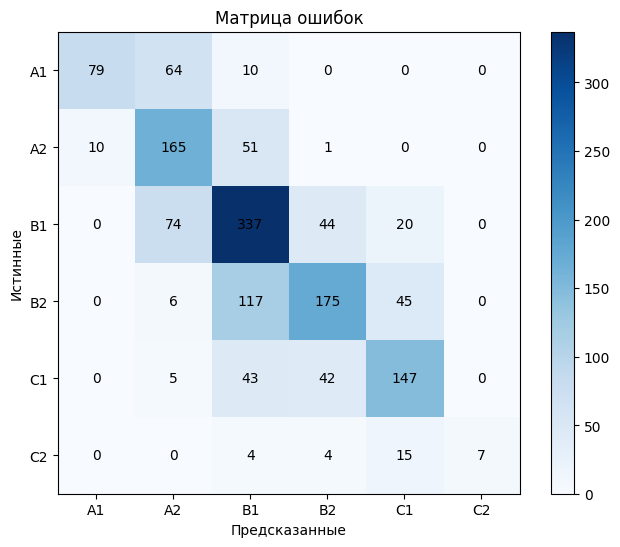

In [15]:
visualize_cm(true_labels, predictions)

# Температура 0.1

In [16]:
c2 = pd.read_csv('c2_augmented_11_temp_0_1.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.033500,0.934938
2,0.525600,0.992051
3,0.119500,1.437024


Обучение завершено за 327.28 секунд (0:05:27)


In [17]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6294
F1 Micro: 0.6294
F1 Macro: 0.5908
F1 Weighted: 0.6274
MAE: 0.4389
              precision    recall  f1-score   support

           1       0.88      0.53      0.66       153
           2       0.54      0.75      0.63       227
           3       0.63      0.68      0.65       475
           4       0.64      0.57      0.60       343
           5       0.64      0.61      0.62       237
           6       1.00      0.23      0.38        30

    accuracy                           0.63      1465
   macro avg       0.72      0.56      0.59      1465
weighted avg       0.65      0.63      0.63      1465



0.6294
0.6294
0.5908
0.6274
0.4389
327.28


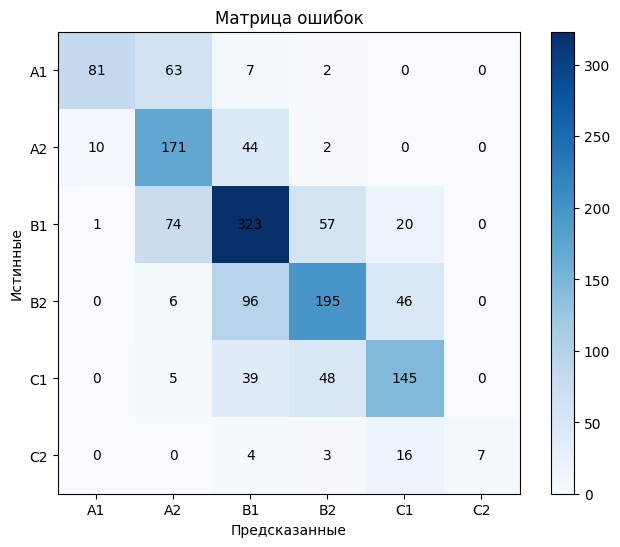

In [18]:
visualize_cm(true_labels, predictions)

# Температура 0.2

In [19]:
c2 = pd.read_csv('c2_augmented_11_temp_0_2.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.043200,0.941528
2,0.517000,0.996552
3,0.132400,1.438197


Обучение завершено за 326.83 секунд (0:05:26)


In [20]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6232
F1 Micro: 0.6232
F1 Macro: 0.5863
F1 Weighted: 0.6204
MAE: 0.4451
              precision    recall  f1-score   support

           1       0.89      0.46      0.61       153
           2       0.52      0.74      0.61       227
           3       0.62      0.70      0.66       475
           4       0.64      0.55      0.59       343
           5       0.64      0.61      0.62       237
           6       1.00      0.27      0.42        30

    accuracy                           0.62      1465
   macro avg       0.72      0.56      0.59      1465
weighted avg       0.65      0.62      0.62      1465



0.6232
0.6232
0.5863
0.6204
0.4451
326.83


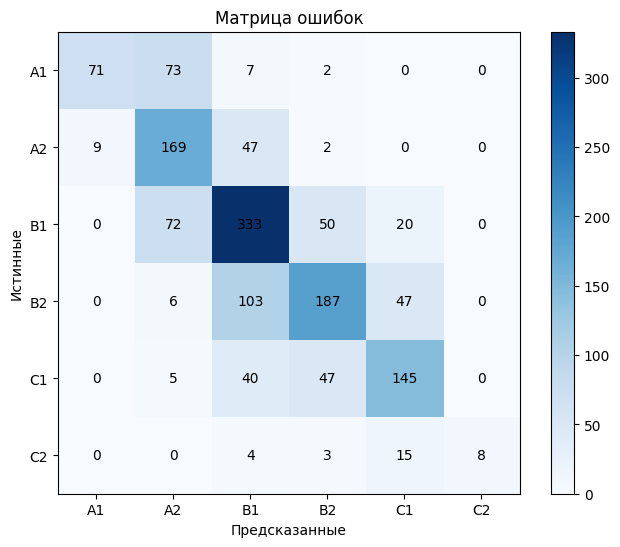

In [21]:
visualize_cm(true_labels, predictions)

# Температура 0.4

In [22]:
c2 = pd.read_csv('c2_augmented_11_temp_0_4.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.031800,0.936201
2,0.517700,0.996774
3,0.124300,1.438509


Обучение завершено за 327.31 секунд (0:05:27)


In [23]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6355
F1 Micro: 0.6355
F1 Macro: 0.6048
F1 Weighted: 0.6336
MAE: 0.4328
              precision    recall  f1-score   support

           1       0.88      0.50      0.64       153
           2       0.53      0.73      0.62       227
           3       0.63      0.71      0.67       475
           4       0.67      0.56      0.61       343
           5       0.65      0.63      0.64       237
           6       1.00      0.30      0.46        30

    accuracy                           0.64      1465
   macro avg       0.73      0.57      0.60      1465
weighted avg       0.66      0.64      0.63      1465



0.6355
0.6355
0.6048
0.6336
0.4328
327.31


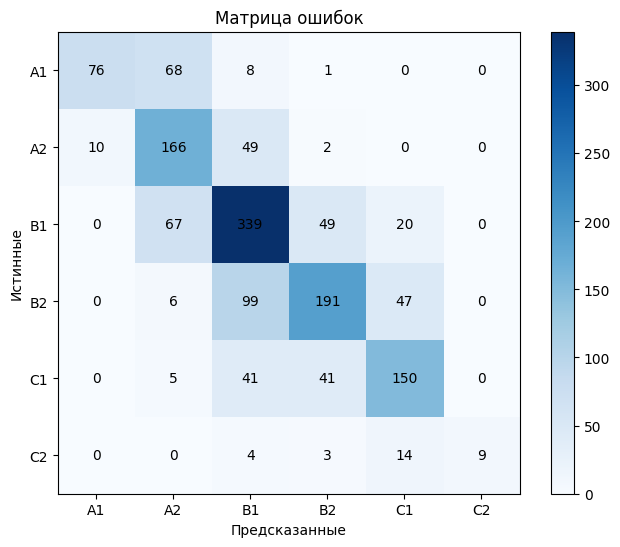

In [24]:
visualize_cm(true_labels, predictions)

# Температура 0.5

In [25]:
c2 = pd.read_csv('c2_augmented_11_temp_0_5.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.029700,0.933165
2,0.516800,1.002773
3,0.136900,1.439753


Обучение завершено за 326.97 секунд (0:05:26)


In [26]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6314
F1 Micro: 0.6314
F1 Macro: 0.5887
F1 Weighted: 0.6290
MAE: 0.4362
              precision    recall  f1-score   support

           1       0.89      0.50      0.64       153
           2       0.53      0.72      0.61       227
           3       0.63      0.71      0.67       475
           4       0.64      0.57      0.60       343
           5       0.64      0.62      0.63       237
           6       1.00      0.23      0.38        30

    accuracy                           0.63      1465
   macro avg       0.72      0.56      0.59      1465
weighted avg       0.65      0.63      0.63      1465



0.6314
0.6314
0.5887
0.6290
0.4362
326.97


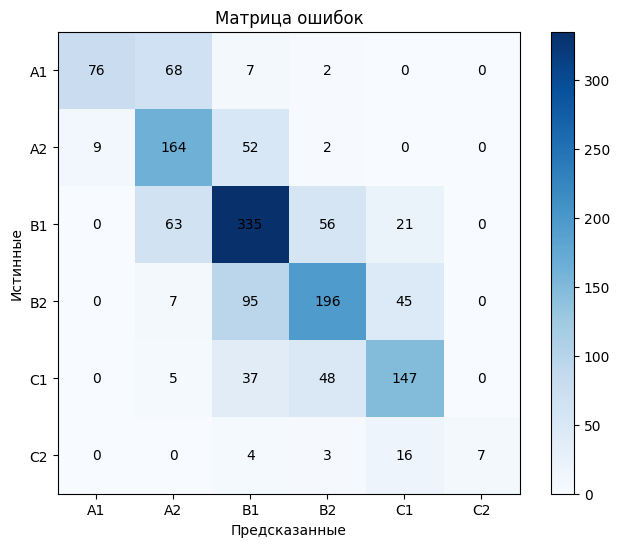

In [27]:
visualize_cm(true_labels, predictions)

# Температура 0.6

In [28]:
c2 = pd.read_csv('c2_augmented_11_temp_0_6.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.033000,0.930849
2,0.530100,0.996521
3,0.136900,1.421728


Обучение завершено за 327.00 секунд (0:05:27)


In [29]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6362
F1 Micro: 0.6362
F1 Macro: 0.6020
F1 Weighted: 0.6339
MAE: 0.4375
              precision    recall  f1-score   support

           1       0.87      0.54      0.67       153
           2       0.55      0.74      0.63       227
           3       0.62      0.72      0.67       475
           4       0.66      0.55      0.60       343
           5       0.63      0.62      0.63       237
           6       1.00      0.27      0.42        30

    accuracy                           0.64      1465
   macro avg       0.72      0.57      0.60      1465
weighted avg       0.66      0.64      0.63      1465



0.6362
0.6362
0.6020
0.6339
0.4375
327.00


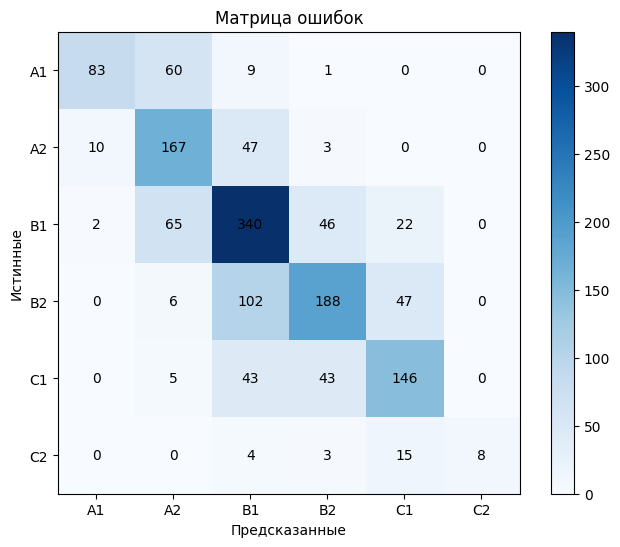

In [30]:
visualize_cm(true_labels, predictions)

# Температура 0.7

In [9]:
c2 = pd.read_csv('c2_augmented_11_temp_0_7.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.045900,0.948837
2,0.554300,0.955332
3,0.138700,1.303318


Обучение завершено за 326.59 секунд (0:05:26)


In [10]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6273
F1 Micro: 0.6273
F1 Macro: 0.5740
F1 Weighted: 0.6236
MAE: 0.4423
              precision    recall  f1-score   support

           1       0.92      0.46      0.62       153
           2       0.54      0.71      0.61       227
           3       0.63      0.72      0.67       475
           4       0.62      0.57      0.59       343
           5       0.66      0.60      0.63       237
           6       0.86      0.20      0.32        30

    accuracy                           0.63      1465
   macro avg       0.70      0.54      0.57      1465
weighted avg       0.65      0.63      0.62      1465



0.6273
0.6273
0.5740
0.6236
0.4423
326.59


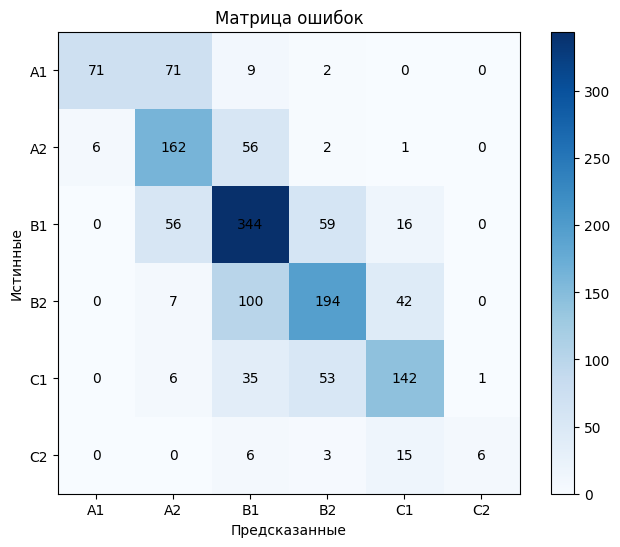

In [11]:
visualize_cm(true_labels, predictions)

# Температура 0.8

In [12]:
c2 = pd.read_csv('c2_augmented_11_temp_0_8.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.043300,0.934302
2,0.522800,0.997460
3,0.136100,1.423856


Обучение завершено за 326.66 секунд (0:05:26)


In [13]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6314
F1 Micro: 0.6314
F1 Macro: 0.5970
F1 Weighted: 0.6290
MAE: 0.4396
              precision    recall  f1-score   support

           1       0.89      0.52      0.66       153
           2       0.54      0.76      0.63       227
           3       0.63      0.70      0.66       475
           4       0.65      0.53      0.58       343
           5       0.64      0.63      0.64       237
           6       0.89      0.27      0.41        30

    accuracy                           0.63      1465
   macro avg       0.71      0.57      0.60      1465
weighted avg       0.65      0.63      0.63      1465



0.6314
0.6314
0.5970
0.6290
0.4396
326.66


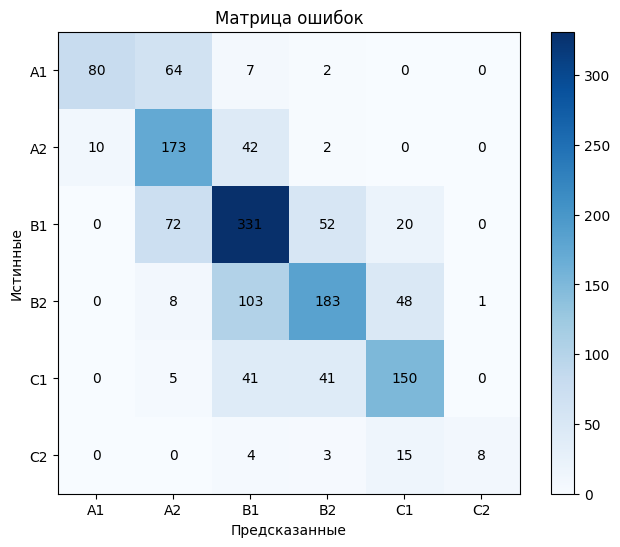

In [14]:
visualize_cm(true_labels, predictions)

# Температура 0.9

In [15]:
c2 = pd.read_csv('c2_augmented_11_temp_0_9.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.034000,0.931969
2,0.535600,0.996429
3,0.140000,1.429163


Обучение завершено за 326.52 секунд (0:05:26)


In [16]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6328
F1 Micro: 0.6328
F1 Macro: 0.5890
F1 Weighted: 0.6304
MAE: 0.4416
              precision    recall  f1-score   support

           1       0.88      0.58      0.70       153
           2       0.57      0.70      0.63       227
           3       0.62      0.71      0.66       475
           4       0.64      0.55      0.59       343
           5       0.62      0.62      0.62       237
           6       1.00      0.20      0.33        30

    accuracy                           0.63      1465
   macro avg       0.72      0.56      0.59      1465
weighted avg       0.65      0.63      0.63      1465



0.6328
0.6328
0.5890
0.6304
0.4416
326.52


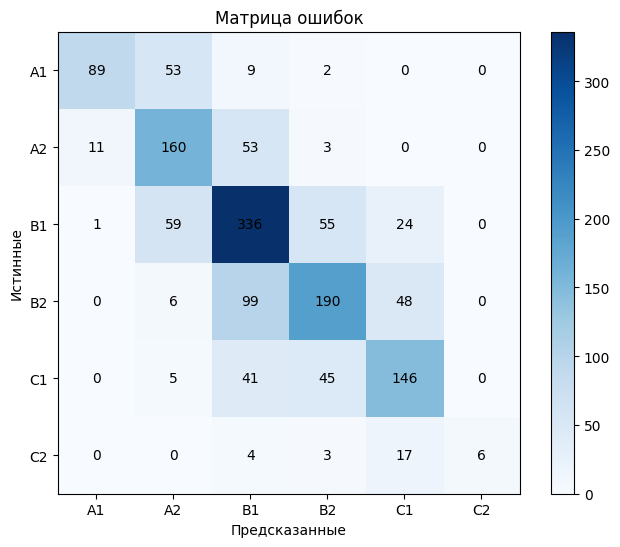

In [17]:
visualize_cm(true_labels, predictions)

# Температура 1.0

In [18]:
c2 = pd.read_csv('c2_augmented_11_temp_1_0.csv')
model, val_dataset, train_time = fit(c2)

FileNotFoundError: [Errno 2] No such file or directory: 'c2_augmented_11_temp_1_0.csv'

In [ ]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

In [ ]:
visualize_cm(true_labels, predictions)